## Project 1: Money Ball!

### See Canvas for assignment dates.

****

## Collaboration policy

This is a **group project** and the team assignments are posted on this Canvas assignment webpage.  **If your name does not appear in a group, you must contact Brent (a private Piazza post) by 11:55 pm, Saturday, Feb. 28th.** Please be welcoming and kind to the students in your group (i.e., be a good classmate).

Please be **welcoming and considerate** when forming groups. You are encouraged to reach out to classmates you may not know well and to act as a supportive, inclusive member of the class. If you are unsure about what is or is not allowed, **you must ask for clarification in advance**. Claiming confusion or uncertainty after the fact will not be accepted as an excuse.

**Collaboration is permitted only within your team.** There may be **no collaboration, discussion, or sharing of work between different teams**. All submitted work must be **entirely the product of your own team**.

To ensure fairness for everyone, the **collaboration policy will be strictly enforced**. Any violation may result in **a zero for all students involved**.

In the Markdown cell below, list the full names of all members of your group.


### Team members

1. Nabiha Choudhury 
2. Zhuoyao Jiang


****
## AI policy

AI may not be used to generate a coding solution. Your solution must be your own work. If you have any questions about what is or isn't allowed, you must ask. Saying afterwards that you didn't understand or were unsure is not an acceptable excuse.

To ensure fairness for everyone, the **AI policy will be strictly enforced**. Any violation may result in **a zero for all students involved**.



****
## Honor pledge

To acknowledge and understand the **Collaboration and AI policies** outlined above, each team member must enter their Onyen and PID in this markdown cell.

1. chnabi PID:730659209
2. Onyen and PID
3. Onyen and PID

****

## Python modules

All the Python modules needed to complete this project are provided to you. 

<span style="background-color: #FFFF00">**No other modules are authorized** and **if other modules are added points will be deducted**.</span>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import r2_score as r2
import pandas as pd 
import math
import warnings
warnings.filterwarnings('ignore')

****

### Baseball Data

<a href=https://www.kaggle.com/open-source-sports/baseball-databank>Baseball Databank</a> is a compilation of historical baseball data from 1871 to 2015. Here, we are using a subset of this databank. Specifically, from 1961 to 2015, which includes these statistics.
- year
- team name
- games played
- wins
- losses
- runs scored
- at bats
- hits
- doubles
- triples
- homeruns
- walks
- strikeouts
- stolen bases
- earned runs allowed
- complete games
- hits allowed
- homeruns allowed

In the following problems, you will be asked to run Ordinary Least Squares Regression (OLSR) to predict wins from various statistics.

Tips:
- This numpy <a href="https://numpy.org/doc/stable/user/absolute_beginners.html">tutorial</a> may be helpful.
- This dataframe <a href="https://pandas.pydata.org/docs/user_guide/indexing.html">selecting, slicing, and extracting tutorial</a> may be helpful.
- This datafame <a href="https://www.geeksforgeeks.org/python/filter-pandas-dataframe-with-multiple-conditions/">conditional filtering tutorial</a> maybe be helpful.
- This Matplotlib <a href="https://matplotlib.org/stable/gallery/mplot3d/scatter3d.html">3D scatter plot tutorial</a> may be helpful.
- The data visualization notebook (see Canvas schedule, 8/21) may be helpful.
- The data representation slides (see Canvas schedule) may be helpful.
- The performance evaluation slides (see Canvas schedule) may be helpful.
- The introduction to supervised learning slides (see Canvas schedule) may be helpful.
- The regression slides (see Canvas schedule) may be helpful.

****

In [3]:
teams_df = pd.read_csv("teams.csv")
teams_df

,year,team name,games played,wins,losses,runs scored,at bats,hits,doubles,triples,homeruns,walks,strikeouts,stolen bases,earned runs allowed,complete games,hits allowed,homeruns allowed
0,1961,Baltimore Orioles,163,95,67,691,5481,1393,227,36,149,581,902,39,526,54,1226,109
1,1961,Boston Red Sox,163,76,86,729,5508,1401,251,37,112,647,847,56,687,35,1472,167
2,1961,Chicago White Sox,163,86,76,765,5556,1475,216,46,138,550,612,100,653,39,1491,158
3,1961,Chicago Cubs,156,64,90,689,5344,1364,238,51,176,539,1027,35,689,34,1492,165
4,1961,Cincinnati Reds,154,93,61,710,5243,1414,247,35,158,423,761,70,575,46,1300,147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1441,2015,Los Angeles Dodgers,162,92,70,667,5385,1346,263,26,187,563,1258,59,553,6,1317,145
1442,2015,San Francisco Giants,162,84,78,696,5565,1486,288,39,136,457,1159,93,597,7,1344,155
1443,2015,Arizona Diamondbacks,162,79,83,720,5649,1494,289,48,154,490,1312,132,659,1,1450,182
1444,2015,San Diego Padres,162,74,88,650,5457,1324,260,36,148,426,1327,82,655,1,1371,171


****

**P1** (10 Points): Data Visualization.

<img src="problem1.png" width="600" style="float: right"/>

**Task Specifications**

Create a filtered version of the **teams_df** dataframe and use it to visualize ``Wins vs Homeruns and Runs Scored`` and ``Wins vs Walks and Doubles`` between 1980 and 2015 (inclusive) for the teams listed below.
- New York Yankees
- Boston Red Sox
- Chicago Cubs
- Baltimore Orioles

To receive full credit, your new dataframe must generate scatter plots identical to the ones provided.

**Figure Requirements**
- All the data (in your dataframe) is used to generate these scatter plots.
- The colors used to generate plots are `blue` for the first plot and `black` for the second plot.
- The plot figure size is 12 inches in width and 12 inches in height.
- The default x-axis, y-axis, and z-axis tick values are used.
- The scatter plot marker size is 30.
- The z_label is rotated 90 degrees, and the `zaxis.labelpad` is set to -0.7.

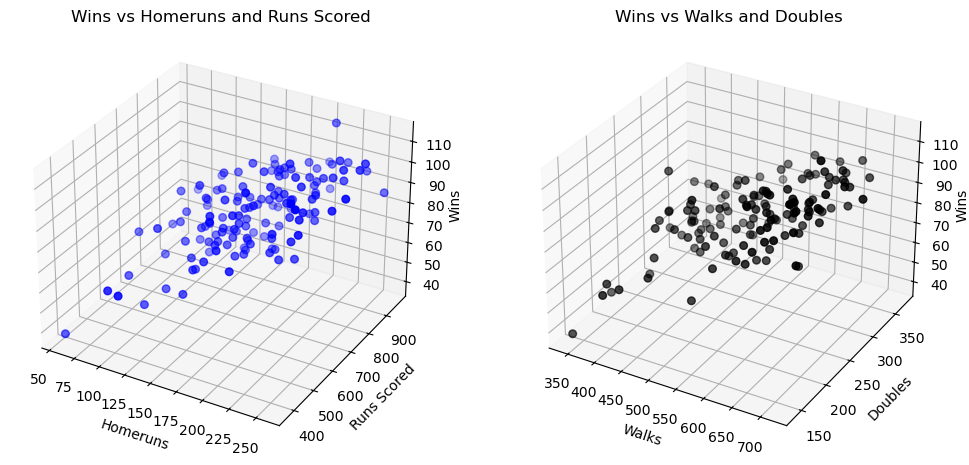

In [52]:
# --------------------------------------
# Add your P1 coding solution below.
# --------------------------------------

filtered_df = teams_df[(teams_df["year"] >= 1980) & (teams_df["year"] <= 2015)]  
filtered_df = filtered_df[filtered_df["team name"].isin(["New York Yankees", "Boston Red Sox", "Chicago Cubs", "Baltimore Orioles"])]
filtered_df = filtered_df[["team name", "year", "wins", "homeruns", "runs scored", "walks", "doubles"]]

xs_1 = filtered_df["homeruns"]
ys_1 = filtered_df["runs scored"]
zs_1 = filtered_df["wins"] 

xs_2 = filtered_df["walks"]
ys_2 = filtered_df["doubles"]
zs_2 = filtered_df["wins"] 


fig, axes = plt.subplots(1, 2, figsize=[12, 12], subplot_kw={'projection': '3d'})


axes[0].scatter(xs_1, ys_1, zs_1, c="blue", s=30)
axes[0].set_xlabel('Homeruns')
axes[0].set_ylabel('Runs Scored')
axes[0].set_zlabel('Wins', rotation=90)
axes[0].zaxis.labelpad = -0.7
axes[0].set_title('Wins vs Homeruns and Runs Scored')

axes[1].scatter(xs_2, ys_2, zs_2, c="black", s=30)
axes[1].set_xlabel('Walks')
axes[1].set_ylabel('Doubles')
axes[1].set_zlabel('Wins', rotation=90)
axes[1].zaxis.labelpad = -0.7
axes[1].set_title('Wins vs Walks and Doubles')

plt.show()



****

**P2** (10 Points): Closed-form OLSR prediction models.

<img src="problem2.png" width="600" style="float: right"/>

Using the **P1** dataframe, you will construct and evaluate two Ordinary Least Squares Regression (OLSR) prediction models. The requirements are given below.

**Dataset Preparation**

Before model construction and evaluation, the P1 dataframe must be randomly shuffled and then partitioned into two sets using an 80/20 split. Specifically, 80% of the data will be used to train, and 20% will be reserved for testing both models. 

**Model Training & Evaluation**

Train two models using the **closed-form solution** to predict Wins based on the following features:

- Model 1: Homeruns and Runs Scored
- Model 2: Walks and Doubles

For each prediction model, report the correlation coefficient ($R^2$) and mean absolute error (MAE) measures for both the training and testing data sets. These may be calculated using the <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html">mean_absolute_error</a> and <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html">r2_score</a> sklearn functions that are provided in authorized Python modules above.

**Figure Requirements**:

To receive full credit, your solution must generate a plot similar to the reference plots. <span style="background-color: #FFFF00">**Note**: because the data is randomly shuffled each time the cell is run, your plots and measures will be slightly different than those provided in the reference plots.</span>

- Only the training data is used to generate the scatter plots for both models.
- The color used to generate the scatter plot is `blue` for the first model and `black` for the second.
- The plane color must be set to `red` and `alpha` must be set to 0.3.
- The plot figure size is 12 inches in width and 6 inches in height.
- The default x-axis, y-axis, and z-axis tick values are used.
- The scatter plot marker size is 30.
- The z_label is rotated 90 degrees, and the `zaxis.labelpad` is set to -0.7.

<ins>Note(s):</ins> Since each OLSR model utilizes two features, the resulting prediction surface is represented as a 2D plane within a 3D coordinate system. Follow these steps to construct the visualization:

- Use `np.linspace` to create $20$ evenly spaced coordinates for each feature, spanning from the minimum to the maximum values found in the corresponding feature in the data frame.
- Use `np.meshgrid` to turn those two 1D arrays into 2D matrices (x and y). This creates a grid of 400 unique coordinate pairs (20×20).
- Apply your optimized $\beta$ parameters to the grid. Specifically, for every point on your grid, calculate the predicted z value (wins) using the plane equation:
    $$z=\beta_0​+\beta_1 ​x+\beta_2 ​y$$
- Use `ax.plot_wireframe()` to draw the resulting regression plane over your scatter plot.


In [ ]:

# --------------------------------------
# Add your P2 coding solution below.
# --------------------------------------







****

**P3** (10 Points): Gradient descent optimized OLSR prediction models.

<img src="problem3.png" width="600" style="float: right"/>

Using the **P1** dataframe, you will construct and evaluate two OLSR prediction models that utilize **gradient descent** to estimate optimal parameters.

**Dataset Preparation**

For model construction and evaluation, you must use 80% of the data for training and 20% for testing. You should use the same split from your solution in **P2**.

**Model Training & Evaluation**

Develop a model to predict Wins based on Homeruns and Runs Scored using an iterative gradient descent approach.

Train multiple gradient descent models using different learning rates.
For each model, compute the sum of squared errors (SSE) on the training set.
  - Use the following learning rates: `[2e-6, 1e-6, 5e-7, 2e-7, 1e-7, 5e-8, 2e-8, 1e-8]`. 
  - Fix the number of training iterations to 50 iterations.
  - Implement an **early stopping condition**. Specifically, if the absolute value of the difference between the SSE and the SSE on the previous iteration is less than 1, then stop training.

Select the model that achieved the lowest SSE on the training set. For this final model, report correlation coefficient ($R^2$) and mean absolute error (MAE) measures for both the training and testing data sets. These may be calculated using the <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html">mean_absolute_error</a> and <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html">r2_score</a> sklearn functions (see authorized Python modules above).

**Figure Requirements**

To receive full credit, your solution must generate a plot similar to the reference plots. <span style="background-color: #FFFF00">**Note**: because the data is randomly shuffled each time the cell is run, your plots and measures will be slightly different than those provided in the reference plots.</span>

- Your figure must be 15 inches wide and 5 inches tall.
- The first plot must be a graph of final SSE against learning rate, colored `orange`. Both axes should be set to a log scale.
- The second plot must be a 3D scatter plot of the training data, colored `blue`, as well as the predicted plane, with the color set to `red` and `alpha` to 0.3. The plot title should contain the training MAE and $R^2$.
- The third plot must be a 3D scatter plot of the testing data, colored `black` as well as the predicted plane, with the color set to `red` and `alpha` to 0.3. The plot title should contain the testing MAE and $R^2$.
- The color used to generate plots is blue.
- The default x-axis, y-axis, and z-axis tick values are used.
- The scatter plot marker size is 30.
- The z_label is rotated 90 degrees, and the `zaxis.labelpad` is set to -0.7.

<ins>Notes:</ins>
- Refer to **P2** to understand how to plot the plane.



In [ ]:
# --------------------------------------
# Add your P3 coding solution below.
# --------------------------------------









****

**P4** (10 Points): Gradient descent optimized OLSR prediction models.

<img src="problem4.png" width="600" style="float: right"/>

Using the **P1** dataframe, you will construct and evaluate two OLSR prediction models that utilize **stochastic batch gradient descent** to estimate optimal parameters.

**Dataset Preparation**

For model construction and evaluation, you must use 80% of the data for training and 20% for testing. You should use the same split from your solution in **P2**.

**Model Training & Evaluation**

Construct one model to predict the number of ``wins`` given  ``Homeruns`` and ``Runs Scored``.

Train multiple gradient descent models using different learning rates.
For each model, compute the sum of squared errors (SSE) on the training set.
  - Use the following batch sizes: `[2,4,8,16,32,64]`.
  - Fix the number of training iterations to 2000 epochs with a learning rate of `1e-7`.
  - No early stopping condition should be implemented.

Afterwards, select the model with the lowest SSE on the entire training set. For this final model, report the correlation coefficient ($R^2$) and mean absolute error (MAE) measures for both the training and testing data sets. These may be calculated using the <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html">mean_absolute_error</a> and <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html">r2_score</a> sklearn functions (see authorized Python modules above).

**Figure Requirements**

To receive full credit, your solution must generate a plot similar to the reference plots. <span style="background-color: #FFFF00">**Note**: because the data is randomly shuffled each time the cell is run, your plots and measures will be slightly different than those provided in the reference plots.</span>

- Your figure must be 15 inches wide and 5 inches tall.
- The first plot must be a graph of final SSE against learning rate, colored **orange**. You do not need to use a log scale.
- The second plot must be a 3D scatter plot of the training data, colored **blue**, as well as the predicted plane, with the color set to `red` and `alpha` to 0.3. The plot title should contain the training MAE and $R^2$.
- The third plot must be a 3D scatter plot of the testing data, colored **black**, as well as the predicted plane, with the color set to `red` and `alpha` to 0.3. The plot title should contain the testing MAE and $R^2$.
- The default x-axis, y-axis, and z-axis tick values are used.
- The scatter plot marker size is 30.
- The z_label is rotated 90 degrees, and the zaxis.labelpad is set to -0.7.

<ins>Note(s):</ins>
- Refer to **P2** to understand how to plot the plane.

In [ ]:
# --------------------------------------
# Add your P4 coding solution below.
# --------------------------------------









